# BNP Paribas- Bussines Case Project 2025/2026
**DATA VISUALIZATION AND PREPROCESSING NOTEBOOK**

**Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

# Index

- [1. Import](#import)
  - [1.1 Import libraries](#import-libraries)
  - [1.2 Import the dataset](#import-the-dataset)
- [2. Data Exploration](#data-Exploration)
  - [2.1 MetaData](#metadata)
  - [2.2 Analysing the Data](#Analysing-the-Data)
  - [2.3 Data Visualization](#Data-visualization)
  - [2.4 Correlation Check](#correlation-check)
- [3. Data Quality & Feature Engineering](#Data-Quality-&-Feature-Engineering)
  - [3.1 Data Quality](#Data-Quality)
  - [3.2 Feature Engineering](#Feature-Engineering)
- [4. Implications for Clustering](#Implications-for-Clustering)
  

<div class="alert alert-block alert-info">

<a class="anchor" id="1. Import">    </a>
# 1. Import
       
</div>


[Back to Index](#index)

<a class="anchor" id="1.1 Import Libraries">

## 1.1 Import Libraries
    
</a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lifelines import CoxPHFitter
from sklearn.metrics import classification_report, roc_auc_score

<a class="anchor" id="1.2 Import the Dataset">

## 1.2 Import the Dataset
    
</a>

In [2]:
#file_path_BNP = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\crc.parquet"
file_path_BNP_teste = r"C:\Users\jcari\OneDrive\Ambiente de Trabalho\NOVA IMS\Business Cases\Case 1\BNP-Paribas-main\BNP-Paribas\Preprocessed_dataset_BNP2_teste.csv"

# Ler o ficheiro parquet
#BNP = pd.read_csv(file_path_BNP)
BNP_teste = pd.read_csv(file_path_BNP_teste)

<a class="anchor" id="2 classification">

## 2 Data Analysis
    
</a>

In [3]:
BNP_teste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185600 entries, 0 to 185599
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   CONTRIB                     185600 non-null  object 
 1   DOSSIER                     185600 non-null  object 
 2   is_san                      185600 non-null  int64  
 3   is_sol                      185600 non-null  int64  
 4   DCREAT                      185600 non-null  object 
 5   DCRD_0                      77788 non-null   object 
 6   CLOSE_DATE                  76646 non-null   object 
 7   DURDEG                      185600 non-null  int64  
 8   RANGPRO_max                 185600 non-null  int64  
 9   RANGCLI_max                 185600 non-null  int64  
 10  delay_sum                   185600 non-null  int64  
 11  MENSALIDADE                 185600 non-null  float64
 12  CRD_min                     185600 non-null  float64
 13  MTFINO        

In [4]:
date_cols = ["DCREAT", "DCRD_0", "CLOSE_DATE", "NEXT_DOSSIER_DATE", "OBS_END_DATE"]

for col in date_cols:
    BNP_teste[col] = pd.to_datetime(BNP_teste[col], errors="coerce")


int32_cols = ["DURDEG", "RANGPRO_max", "RANGCLI_max", "is_risky", "CSP"]

for col in int32_cols:
    BNP_teste[col] = BNP_teste[col].astype("Int32")


float64_nullable_cols = ["RISKA_mean", "count_cl_mean", "subcount_total_mean"]

for col in float64_nullable_cols:
    BNP_teste[col] = BNP_teste[col].astype("Float64")


object_cols = ["DOSSIER", "POLE", "PRODALP", "PAGAMENTO", "NATIO", "PTT", 
               "MODCONTACTO", "kp_sqe", "sdem_SITFAM", "sdem_HABITAT"]

for col in object_cols:
    BNP_teste[col] = BNP_teste[col].astype("object")


In [5]:
BNP_teste.describe(include = 'all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
CONTRIB,185600,148729,364aad4f1733591b129753f295cca317a449f207c209bd...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOSSIER,185600,185592,a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_san,185600.0,NaN,NaN,NaN,0.266622,0.0,0.0,0.0,1.0,1.0,0.442194
is_sol,185600.0,NaN,NaN,NaN,0.146342,0.0,0.0,0.0,0.0,1.0,0.353449
DCREAT,185600,NaN,NaN,NaN,2022-05-19 23:17:39.672414208,1996-06-14 00:00:00,2021-01-22 00:00:00,2023-03-10 00:00:00,2024-09-25 00:00:00,2025-12-02 00:00:00,NaN
DCRD_0,77788,NaN,NaN,NaN,2024-10-15 10:35:42.932071936,2024-01-31 00:00:00,2024-02-29 00:00:00,2024-08-31 00:00:00,2025-04-30 00:00:00,2025-11-30 00:00:00,NaN
CLOSE_DATE,76646,NaN,NaN,NaN,2024-10-13 23:29:11.292956928,2024-01-31 00:00:00,2024-02-29 00:00:00,2024-08-31 00:00:00,2025-04-30 00:00:00,2025-11-30 00:00:00,NaN
DURDEG,185600.0,<NA>,<NA>,<NA>,71.369898,11.0,48.0,84.0,84.0,156.0,29.800907
RANGPRO_max,185600.0,<NA>,<NA>,<NA>,30.658712,0.0,10.0,24.0,47.0,120.0,25.133634
RANGCLI_max,185600.0,<NA>,<NA>,<NA>,43.685851,0.0,22.0,38.0,61.0,400.0,28.57039


In [6]:
pd.set_option('display.max_columns', None)
BNP_teste

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN,OBS_END_DATE,DOSSIER_DURATION_DAYS,N_PREVIOUS_DOSSIERS,AVG_DURATION,previous_churn_rate,time_between_dossiers,count_cl_mean,montvenc_cl_mean,montabatv_cl_mean,dividas_cl_mean,subcount_total_mean,montenc_total_mean,montabatv_total_mean,dividas_total_mean,HIGH_RISK_CURRENT,kp_sqe,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,1,0,2024-06-25,2024-09-30,2024-09-30,84,3,19,1,158.359889,0.000,8000.00,1395.993500,0.0,0.0,0.0,0.000000,P,EP,118.0,P,74,P,8600,W,NaT,NaN,True,2024-09-30,97,0,-1.0,-1.0,-1.0,0.36,0.000,0.0,2565.7936,5.28,0.000,0.0,17196.2076,0.0,H,2,1,120.0,0.033333,10,S,F,33,0.272727
1,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc2063...,1,0,2024-09-13,2025-11-30,2025-11-30,120,13,19,1,280.401466,0.000,16000.00,1513.466000,0.0,0.0,0.0,0.000000,P,EP,118.0,P,80,P,8600,W,NaT,NaN,True,2025-11-30,443,1,97.0,1.0,80.0,0.36,0.000,0.0,2565.7936,5.28,0.000,0.0,17196.2076,0.0,H,2,1,120.0,0.033333,10,S,F,33,0.272727
2,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,0,0,2018-03-29,NaT,NaT,120,91,91,0,347.447280,8115.247,20000.00,1113.258000,0.0,1.0,0.0,15.106391,P,EP,120.0,P,80,P,2845,A,NaT,NaN,NaN,2025-11-30,2803,0,-1.0,-1.0,-1.0,4.32,0.000,0.0,26448.0320,9.72,0.000,0.0,34000.1492,0.0,D,1,0,120.0,0.675000,10,C,P,52,0.090909
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,0,1,2001-09-21,2024-03-31,2024-03-31,60,21,21,0,424.699203,0.000,13467.54,678.483000,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,NaT,NaN,True,2024-03-31,8227,0,-1.0,-1.0,-1.0,1.32,0.000,0.0,7120.2352,5.2,0.000,0.0,26643.3160,0.0,Unknown,1,1,60.0,0.178571,8,C,A,44,0.166667
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,0,1,2001-09-27,2024-03-31,2024-03-31,60,21,21,0,184.214593,0.000,5985.57,678.483000,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,NaT,NaN,True,2024-03-31,8221,1,8227.0,1.0,6.0,1.32,0.000,0.0,7120.2352,5.2,0.000,0.0,26643.3160,0.0,Unknown,1,1,60.0,0.178571,8,C,A,44,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185595,fffc991d73df732084dab58938d520b8a5d8712474fa53...,8a1945dd1c8ef5d381bef27f69ef52bd6b19729822aea7...,0,1,2021-02-12,2024-01-31,2024-01-31,34,34,34,0,57.095138,0.000,1500.00,896.196000,0.0,1.0,0.0,0.000000,P,EP,118.0,P,80,P,4400,W,NaT,NaN,True,2024-01-31,1083,0,-1.0,-1.0,-1.0,0.36,0.000,0.0,106.0964,2.36,0.000,0.0,107.2952,0.0,Unknown,1,1,0.0,0.000000,4,S,P,33,0.200000
185596,fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a...,b6e4983596a5a38f9bfd54da8bff33bcae0bfc46138f9a...,0,0,2021-06-17,NaT,NaT,60,53,53,0,416.654611,2563.528,15000.00,1623.880000,0.0,0.0,0.0,0.000000,P,EP,120.0,P,80,P,9560,W,NaT,NaN,NaN,2025-11-30,1627,0,-1.0,-1.0,-1.0,1.0,0.000,0.0,5612.6424,3.0,0.000,0.0,27869.1408,0.0,Unknown,1,1,60.0,0.716667,3,U,F,33,0.250000
185597,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a...,1,0,2022-03-24,2024-03-31,2024-03-31,84,23,34,1,267.471639,0.000,12000.00,955.766667,0.333333,0.0,0.0,233.510333,P,EPF,117.0,P,80,P,2845,A,NaT,NaN,True,2024-03-31,738,0,-1.0,-1.0,-1.0,2.12,0.000,0.0,16939.2728,3.32,0.000,0.0,20607.9564,0.0,Unknown,1,1,156.0,0.064103,17,X,F,33,0.055556
185598,ffff943c736f98d4840f65328ba372a29689312dd781b4...,028095f193e6a9ceaf6878e2f0

## 3. Feature Engineering

In [7]:
BNP_teste['CHURN_DATE'] = pd.NaT

#only the dossiers that churned
BNP_teste.loc[BNP_teste['CHURN'] == True, 'CHURN_DATE'] = (
    BNP_teste.loc[BNP_teste['CHURN'] == True, 'CLOSE_DATE'] + pd.Timedelta(days=30)
)

In [8]:
BNP_teste[['CLOSE_DATE','CHURN','CHURN_DATE']].head(10)

,CLOSE_DATE,CHURN,CHURN_DATE
0,2024-09-30,True,2024-10-30
1,2025-11-30,True,2025-12-30
2,NaT,NaN,NaT
3,2024-03-31,True,2024-04-30
4,2024-03-31,True,2024-04-30
5,2024-01-31,True,2024-03-01
6,NaT,NaN,NaT
7,NaT,NaN,NaT
8,2024-03-31,True,2024-04-30
9,NaT,NaN,NaT


In [9]:
BNP_teste['days_to_churn'] = (BNP_teste['CHURN_DATE'] - BNP_teste['DCREAT']).dt.days

In [10]:
BNP_teste[['DCREAT', 'CLOSE_DATE', 'CHURN', 'CHURN_DATE', 'days_to_churn']].head(15)

,DCREAT,CLOSE_DATE,CHURN,CHURN_DATE,days_to_churn
0,2024-06-25,2024-09-30,True,2024-10-30,127.0
1,2024-09-13,2025-11-30,True,2025-12-30,473.0
2,2018-03-29,NaT,NaN,NaT,NaN
3,2001-09-21,2024-03-31,True,2024-04-30,8257.0
4,2001-09-27,2024-03-31,True,2024-04-30,8251.0
5,2019-01-28,2024-01-31,True,2024-03-01,1859.0
6,2019-09-23,NaT,NaN,NaT,NaN
7,2023-01-09,NaT,NaN,NaT,NaN
8,2007-06-29,2024-03-31,True,2024-04-30,6150.0
9,2021-02-10,NaT,NaN,NaT,NaN


In [11]:
max_obs_date = BNP_teste['OBS_END_DATE'].max()

BNP_teste['obs_time_since_creation'] = (max_obs_date - BNP_teste['DCREAT']).dt.days

In [12]:
BNP_teste

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN,OBS_END_DATE,DOSSIER_DURATION_DAYS,N_PREVIOUS_DOSSIERS,AVG_DURATION,previous_churn_rate,time_between_dossiers,count_cl_mean,montvenc_cl_mean,montabatv_cl_mean,dividas_cl_mean,subcount_total_mean,montenc_total_mean,montabatv_total_mean,dividas_total_mean,HIGH_RISK_CURRENT,kp_sqe,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio,CHURN_DATE,days_to_churn,obs_time_since_creation
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,1,0,2024-06-25,2024-09-30,2024-09-30,84,3,19,1,158.359889,0.000,8000.00,1395.993500,0.0,0.0,0.0,0.000000,P,EP,118.0,P,74,P,8600,W,NaT,NaN,True,2024-09-30,97,0,-1.0,-1.0,-1.0,0.36,0.000,0.0,2565.7936,5.28,0.000,0.0,17196.2076,0.0,H,2,1,120.0,0.033333,10,S,F,33,0.272727,2024-10-30,127.0,523
1,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc2063...,1,0,2024-09-13,2025-11-30,2025-11-30,120,13,19,1,280.401466,0.000,16000.00,1513.466000,0.0,0.0,0.0,0.000000,P,EP,118.0,P,80,P,8600,W,NaT,NaN,True,2025-11-30,443,1,97.0,1.0,80.0,0.36,0.000,0.0,2565.7936,5.28,0.000,0.0,17196.2076,0.0,H,2,1,120.0,0.033333,10,S,F,33,0.272727,2025-12-30,473.0,443
2,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,0,0,2018-03-29,NaT,NaT,120,91,91,0,347.447280,8115.247,20000.00,1113.258000,0.0,1.0,0.0,15.106391,P,EP,120.0,P,80,P,2845,A,NaT,NaN,NaN,2025-11-30,2803,0,-1.0,-1.0,-1.0,4.32,0.000,0.0,26448.0320,9.72,0.000,0.0,34000.1492,0.0,D,1,0,120.0,0.675000,10,C,P,52,0.090909,NaT,NaN,2803
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,0,1,2001-09-21,2024-03-31,2024-03-31,60,21,21,0,424.699203,0.000,13467.54,678.483000,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,NaT,NaN,True,2024-03-31,8227,0,-1.0,-1.0,-1.0,1.32,0.000,0.0,7120.2352,5.2,0.000,0.0,26643.3160,0.0,Unknown,1,1,60.0,0.178571,8,C,A,44,0.166667,2024-04-30,8257.0,8836
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,0,1,2001-09-27,2024-03-31,2024-03-31,60,21,21,0,184.214593,0.000,5985.57,678.483000,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,NaT,NaN,True,2024-03-31,8221,1,8227.0,1.0,6.0,1.32,0.000,0.0,7120.2352,5.2,0.000,0.0,26643.3160,0.0,Unknown,1,1,60.0,0.178571,8,C,A,44,0.166667,2024-04-30,8251.0,8830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185595,fffc991d73df732084dab58938d520b8a5d8712474fa53...,8a1945dd1c8ef5d381bef27f69ef52bd6b19729822aea7...,0,1,2021-02-12,2024-01-31,2024-01-31,34,34,34,0,57.095138,0.000,1500.00,896.196000,0.0,1.0,0.0,0.000000,P,EP,118.0,P,80,P,4400,W,NaT,NaN,True,2024-01-31,1083,0,-1.0,-1.0,-1.0,0.36,0.000,0.0,106.0964,2.36,0.000,0.0,107.2952,0.0,Unknown,1,1,0.0,0.000000,4,S,P,33,0.200000,2024-03-01,1113.0,1752
185596,fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a...,b6e4983596a5a38f9bfd54da8bff33bcae0bfc46138f9a...,0,0,2021-06-17,NaT,NaT,60,53,53,0,416.654611,2563.528,15000.00,1623.880000,0.0,0.0,0.0,0.000000,P,EP,120.0,P,80,P,9560,W,NaT,NaN,NaN,2025-11-30,1627,0,-1.0,-1.0,-1.0,1.0,0.000,0.0,5612.6424,3.0,0.000,0.0,27869.1408,0.0,Unknown,1,1,60.0,0.716667,3,U,F,33,0.250000,NaT,NaN,1627
185597,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,5f58cce05624b68e1c810c7eddea58a455e4e519b1d56a...,1,0,2022-03-24,2024-03-31,2024-03-31,84,23,34,1,267.471639,0.000,12000.00,955.766667,0.333333,0.0,0.0,233.510333,P,EPF,117.0,P,80,P,2845,A,NaT,NaN,True,2024-03-31,738,0,-1

In [13]:
#tentativa da minha ideia, nao sei se fica para a versao final
'''limit = [30, 60, 90]

for i in limit:
    col = f"target_{i}"
    
    BNP_teste[col] = pd.NA
    
    #confirmed churn untill the limit
    BNP_teste.loc[(BNP_teste['days_to_churn'].notna()) & (BNP_teste['days_to_churn'] <= i), col] = 1
    
    #didn't churn in this limit
    BNP_teste.loc[(BNP_teste['CHURN'] == False) & (BNP_teste['obs_time_since_creation'] >= i), col] = 0
    
    BNP_teste[col] = BNP_teste[col].astype("Int32")'''

'limit = [30, 60, 90]\n\nfor i in limit:\n    col = f"target_{i}"\n    \n    BNP_teste[col] = pd.NA\n    \n    #confirmed churn untill the limit\n    BNP_teste.loc[(BNP_teste[\'days_to_churn\'].notna()) & (BNP_teste[\'days_to_churn\'] <= i), col] = 1\n    \n    #didn\'t churn in this limit\n    BNP_teste.loc[(BNP_teste[\'CHURN\'] == False) & (BNP_teste[\'obs_time_since_creation\'] >= i), col] = 0\n    \n    BNP_teste[col] = BNP_teste[col].astype("Int32")'

In [14]:
'''for i in [30, 60, 90]:
    print(f"\n--- target_{i} ---")
    print(BNP_teste[f"target_{i}"].value_counts(dropna=False))'''

'for i in [30, 60, 90]:\n    print(f"\n--- target_{i} ---")\n    print(BNP_teste[f"target_{i}"].value_counts(dropna=False))'

In [15]:
BNP_teste['days_to_churn'].describe()

count    74532.000000
mean      1480.881487
std       1518.324719
min         30.000000
25%        505.000000
50%       1105.000000
75%       1928.000000
max      10182.000000
Name: days_to_churn, dtype: float64

First, let's define our survival event (churn) and it's duration:

In [16]:
BNP_teste['event'] = (BNP_teste['CHURN'] == True).astype(int)

BNP_teste['duration'] = BNP_teste['DOSSIER_DURATION_DAYS']

## 4. Data Separation

In [17]:
train_full = BNP_teste[BNP_teste['CLOSE_DATE'].notna()].copy()
test_data = BNP_teste[BNP_teste['CLOSE_DATE'].isna()].copy()

In [18]:
train_data, val_data = train_test_split(train_full,
                                        test_size = 0.2,
                                        random_state = 42,
                                        stratify=train_full['event'])

In [19]:
print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test (open dossiers):", test_data.shape)

print("\nEvent distribution train")
print(train_data['event'].value_counts())

print("\nEvent distribution validation")
print(val_data['event'].value_counts())

Train: (61316, 60)
Validation: (15330, 60)
Test (open dossiers): (108954, 60)

Event distribution train
event
1    59625
0     1691
Name: count, dtype: int64

Event distribution validation
event
1    14907
0      423
Name: count, dtype: int64


## 5. Kaplan-Meier Survival Curve

In [20]:
#pip install lifelines

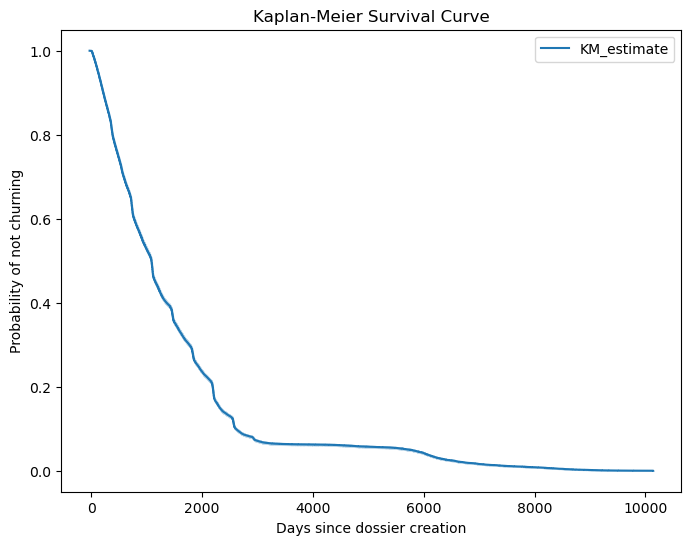

In [21]:
kmf = KaplanMeierFitter()

kmf.fit(durations=train_data['duration'],
        event_observed=train_data['event'])

plt.figure(figsize=(8,6))
kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Days since dossier creation")
plt.ylabel("Probability of not churning")

plt.show()

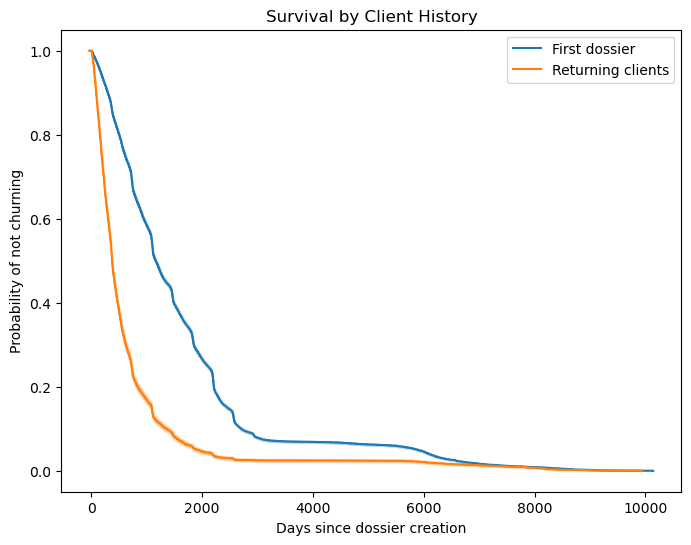

In [22]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for label, group in train_data.groupby(train_data['N_PREVIOUS_DOSSIERS'] > 0):
    
    label_name = "Returning clients" if label else "First dossier"
    
    kmf.fit(durations=group['duration'],
            event_observed=group['event'],
            label=label_name)
    
    kmf.plot_survival_function()

plt.title("Survival by Client History")
plt.xlabel("Days since dossier creation")
plt.ylabel("Probability of not churning")

plt.show()

## 6. Feature Selection for Survival Methods

removemos features que possam introduzir data leakage ou que sejam de identificativos

In [23]:
features_for_survival = ['DURDEG', 'MENSALIDADE', 'CRD_min', 'MTFINO', 'SREC',
                        'RESSO_mean', 'NBENF_mean',
                        'N_PREVIOUS_DOSSIERS', 'previous_churn_rate',
                        'count_cl_mean', 'montvenc_cl_mean', 'montabatv_cl_mean', 'dividas_cl_mean',
                        'ks_score_tier', 'HIGH_RISK_CURRENT', 'is_risky',
                        'sdem_age', 'active_credit_ratio']

In [24]:
X_train = train_data[features_for_survival].copy()
X_val = val_data[features_for_survival].copy()

y_train = train_data[['duration','event']]
y_val = val_data[['duration','event']]

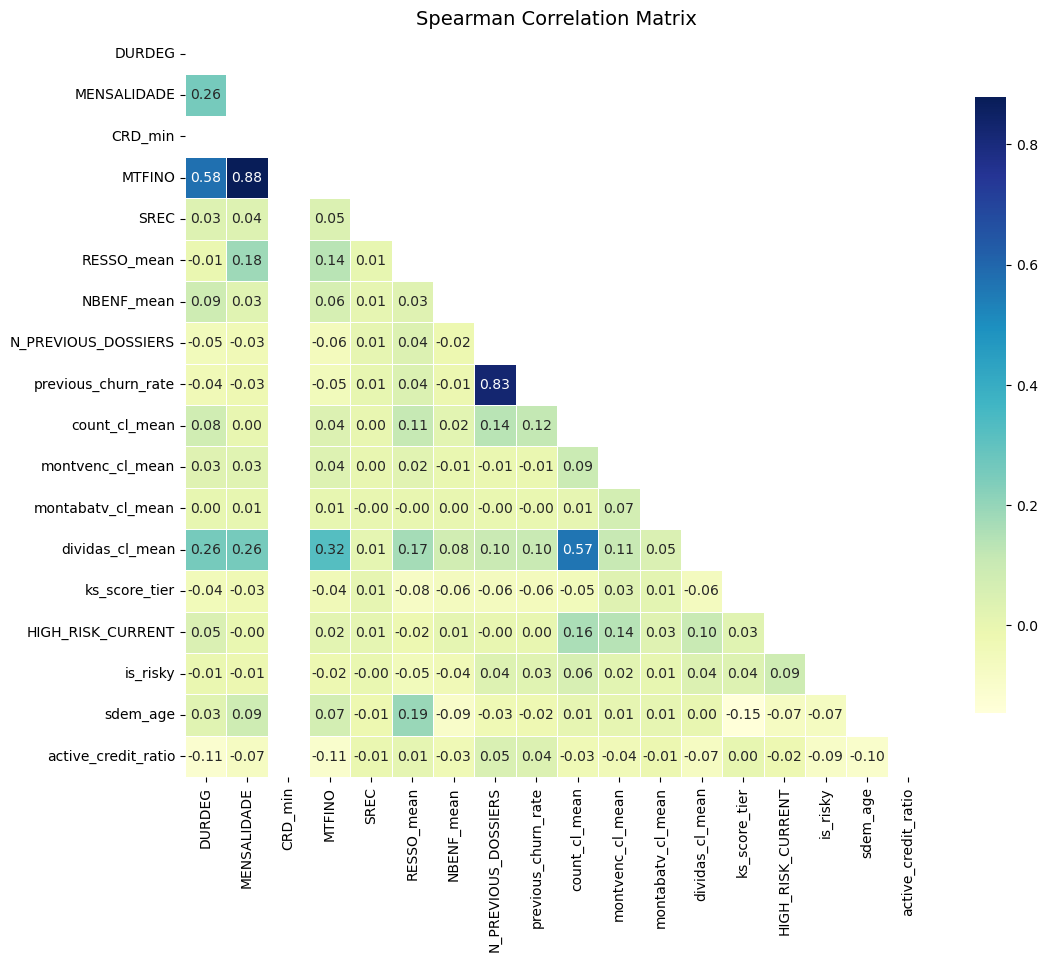

In [25]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap='YlGnBu',            #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

'''This function visualises a correlation matrix using a heatmap to
facilitate interpretation of relationships between variables. By 
masking the upper triangle of the matrix, the plot avoids redundant
information and improves the readability. '''

cor_heatmap(X_train.corr())

In [26]:
X_train.corr()

,DURDEG,MENSALIDADE,CRD_min,MTFINO,SREC,RESSO_mean,NBENF_mean,N_PREVIOUS_DOSSIERS,previous_churn_rate,count_cl_mean,montvenc_cl_mean,montabatv_cl_mean,dividas_cl_mean,ks_score_tier,HIGH_RISK_CURRENT,is_risky,sdem_age,active_credit_ratio
DURDEG,1.000000,0.255411,NaN,0.575669,0.034667,-0.006709,0.086968,-0.047088,-0.037231,0.078865,0.032060,0.003157,0.257148,-0.044859,0.048648,-0.009140,0.029451,-0.113953
MENSALIDADE,0.255411,1.000000,NaN,0.878684,0.035541,0.182802,0.027618,-0.034222,-0.025757,0.001268,0.027681,0.005702,0.256919,-0.029401,-0.004265,-0.010688,0.089118,-0.072882
CRD_min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MTFINO,0.575669,0.878684,NaN,1.000000,0.045380,0.137696,0.061099,-0.056536,-0.048536,0.038993,0.035900,0.005453,0.324015,-0.040036,0.015422,-0.019081,0.071558,-0.105815
SREC,0.034667,0.035541,NaN,0.045380,1.000000,0.005282,0.008564,0.006595,0.005024,0.000667,0.001731,-0.001076,0.010477,0.006444,0.012687,-0.002168,-0.014615,-0.007879
RESSO_mean,-0.006709,0.182802,NaN,0.137696,0.005282,1.000000,0.030938,0.040246,0.043805,0.112504,0.024045,-0.002012,0.172915,-0.081394,-0.018728,-0.046608,0.191875,0.011345
NBENF_mean,0.086968,0.027618,NaN,0.061099,0.008564,0.030938,1.000000,-0.015977,-0.012286,0.020917,-0.005930,0.000421,0.076978,-0.061864,0.011724,-0.037842,-0.093083,-0.030095
N_PREVIOUS_DOSSIERS,-0.047088,-0.034222,NaN,-0.056536,0.006595,0.040246,-0.015977,1.000000,0.825530,0.137581,-0.009331,-0.004679,0.100723,-0.061191,-0.001901,0.036371,-0.029888,0.051324
previous_churn_rate,-0.037231,-0.025757,NaN,-0.048536,0.005024,0.043805,-0.012286,0.825530,1.000000,0.117565,-0.006382,-0.004838,0.102462,-0.058058,0.000024,0.028064,-0.024996,0.040723
count_cl_mean,0.078865,0.001268,NaN,0.038993,0.000667,0.112504,0.020917,0.137581,0.117565,1.000000,0.094755,0.007331,0.565212,-0.046707,0.161961,0.057563,0.007218,-0.032112


Alta correlação:
- Mensalidade e MTFINO - mantemos MTFINO;
- previous_churn_rate e N_PREVIOUS_DOSSIERS	- mantemos previous_churn_rate

dropamos tbm crd_min (é sempre 0 nestes dossiers fechados)

In [27]:
cols_to_drop = ['MENSALIDADE', 'N_PREVIOUS_DOSSIERS', 'CRD_min']

X_train = train_data[features_for_survival].drop(columns=cols_to_drop)
X_val = val_data[features_for_survival].drop(columns=cols_to_drop)

In [28]:
train_survival = pd.concat([X_train, y_train], axis=1)

val_survival = pd.concat([X_val, y_val], axis=1)

In [29]:
print("Train shape:", train_survival.shape)
print("Validation shape:", val_survival.shape)

Train shape: (61316, 17)
Validation shape: (15330, 17)


## 6.2 Embedded Methods

treinar 3 modelos:
- Random Forest;
- XGBoost;
- Penalized Cox. 

random forest e XGBoost apenas preveem variaveis importantes para o churn, Penalized Cox tem em conta a duração, que tambem será importante para survival.

## 6.2.1 Random Forest 

In [30]:
#same numerical features as before
rf_features = features_for_survival.copy()

#removing those we determined were not useful
cols_to_drop = ['MENSALIDADE', 'N_PREVIOUS_DOSSIERS', 'CRD_min']
rf_features = [col for col in rf_features if col not in cols_to_drop]

#preparing our data for random forest
X_train_rf = train_data[rf_features].copy()
X_val_rf = val_data[rf_features].copy()

y_train_rf = train_data['CHURN'].astype(int)
y_val_rf = val_data['CHURN'].astype(int)

#random forest model
rf = RandomForestClassifier(n_estimators = 300, 
                            random_state = 42, 
                            class_weight = 'balanced', 
                            n_jobs = -1)

rf.fit(X_train_rf, y_train_rf)

#target predictions
y_val_pred = rf.predict(X_val_rf)
y_val_prob = rf.predict_proba(X_val_rf)[:, 1]

print(classification_report(y_val_rf, y_val_pred))
print("Validation ROC-AUC:", roc_auc_score(y_val_rf, y_val_prob))

# feature importance
rf_importance = pd.Series(rf.feature_importances_, index=X_train_rf.columns).sort_values(ascending=False)

print(rf_importance)

              precision    recall  f1-score   support

           0       0.89      0.02      0.04       423
           1       0.97      1.00      0.99     14907

    accuracy                           0.97     15330
   macro avg       0.93      0.51      0.51     15330
weighted avg       0.97      0.97      0.96     15330

Validation ROC-AUC: 0.7076881392767547
active_credit_ratio    0.156136
dividas_cl_mean        0.154846
count_cl_mean          0.129794
RESSO_mean             0.127219
sdem_age               0.101843
MTFINO                 0.099384
DURDEG                 0.064945
previous_churn_rate    0.042217
NBENF_mean             0.036291
SREC                   0.024376
montvenc_cl_mean       0.019127
is_risky               0.015745
ks_score_tier          0.015470
HIGH_RISK_CURRENT      0.012500
montabatv_cl_mean      0.000107
dtype: float64


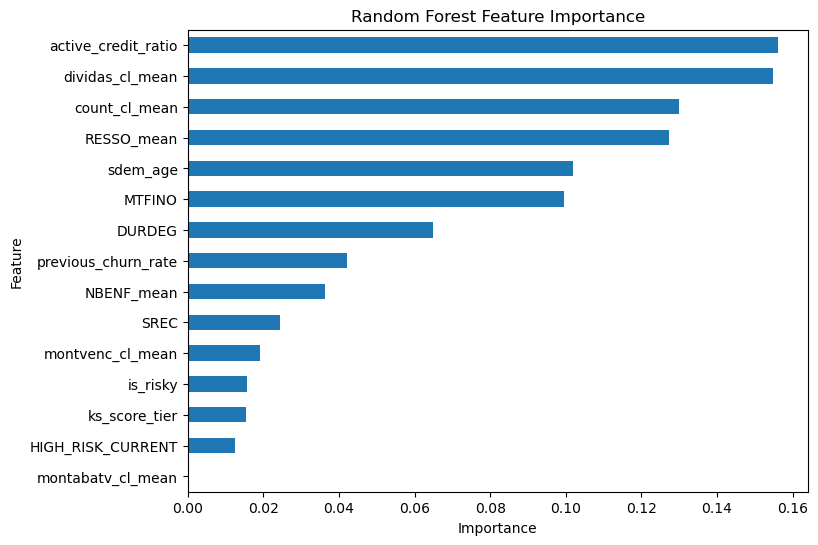

In [31]:
plt.figure(figsize=(8,6))
rf_importance.sort_values(ascending=True).plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

O Random Forest sugere que as variáveis mais informativas são:
- active_credit_ratio
- dividas_cl_mean
- count_cl_mean
- RESSO_mean
- sdem_age
- MTFINO

## 6.2.2 XGBoost

In [32]:
#pip install xgboost

In [33]:
##same numerical features as before
xgb_features = features_for_survival.copy()

#removing those we determined were not useful
cols_to_drop = ['MENSALIDADE', 'N_PREVIOUS_DOSSIERS', 'CRD_min']
xgb_features = [col for col in xgb_features if col not in cols_to_drop]

#preparing our data for xgboost
X_train_xgb = train_data[xgb_features].copy()
X_val_xgb = val_data[xgb_features].copy()

y_train_xgb = train_data['CHURN'].astype(int)
y_val_xgb = val_data['CHURN'].astype(int)

#weights
neg = (y_train_xgb == 0).sum()
pos = (y_train_xgb == 1).sum()
scale_pos_weight = neg / pos

print("Negative class count:", neg)
print("Positive class count:", pos)
print("scale_pos_weight:", scale_pos_weight)

#xgboost model
xgb_model = XGBClassifier(n_estimators = 300,
                          max_depth = 4,
                          learning_rate = 0.05,
                          subsample = 0.8,
                          colsample_bytree = 0.8,
                          random_state = 42,
                          n_jobs = -1,
                          eval_metric = 'logloss',
                          scale_pos_weight = scale_pos_weight)

xgb_model.fit(X_train_xgb, y_train_xgb)

##target predictions
y_val_pred_xgb = xgb_model.predict(X_val_xgb)
y_val_prob_xgb = xgb_model.predict_proba(X_val_xgb)[:, 1]

print(classification_report(y_val_xgb, y_val_pred_xgb))
print("Validation ROC-AUC:", roc_auc_score(y_val_xgb, y_val_prob_xgb))

# feature importance
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train_xgb.columns).sort_values(ascending=False)

print(xgb_importance)

Negative class count: 1691
Positive class count: 59625
scale_pos_weight: 0.028360587002096437
              precision    recall  f1-score   support

           0       0.05      0.67      0.10       423
           1       0.99      0.65      0.78     14907

    accuracy                           0.65     15330
   macro avg       0.52      0.66      0.44     15330
weighted avg       0.96      0.65      0.77     15330

Validation ROC-AUC: 0.7309776881440344
active_credit_ratio    0.184509
previous_churn_rate    0.174332
dividas_cl_mean        0.090678
is_risky               0.071011
ks_score_tier          0.059825
count_cl_mean          0.057522
DURDEG                 0.053624
MTFINO                 0.049888
montvenc_cl_mean       0.047943
HIGH_RISK_CURRENT      0.045733
NBENF_mean             0.044567
RESSO_mean             0.041786
sdem_age               0.041319
SREC                   0.037261
montabatv_cl_mean      0.000000
dtype: float32


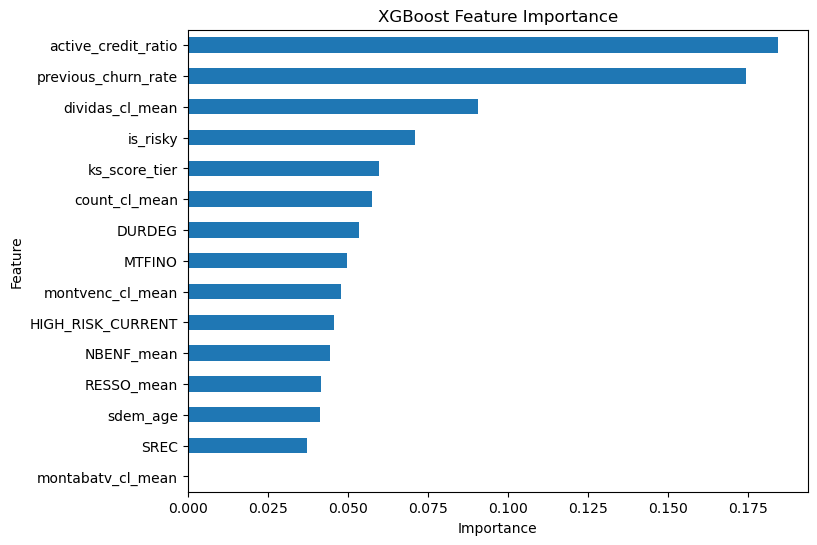

In [34]:
plt.figure(figsize=(8,6))
xgb_importance.sort_values(ascending=True).plot(kind='barh')
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

O XGBoost sugere que as variáveis mais informativas são:
- active_credit_ratio
- previous_churn_rate
- dividas_cl_mean
- is_risky
- ks_score_tier

## 6.2.3 Penalized Cox

In [35]:
#Penalized cox model
cph_l1 = CoxPHFitter(penalizer = 0.1, l1_ratio = 1)

cph_l1.fit(train_survival, duration_col='duration', event_col='event')

#checking the coeficients
cox_l1_results = cph_l1.summary[['coef', 'exp(coef)', 'p']]

#feature importance
cox_l1_sorted = cox_l1_results.reindex(cox_l1_results['coef'].abs().sort_values(ascending=False).index)

print("\nFeatures ordered by importance (|coef|):")
print(cox_l1_sorted)

#checking to see if L1 removed any feature
selected_features = cox_l1_results[cox_l1_results['coef'] != 0]

if len(selected_features) == len(cox_l1_results):
    print("\nLasso did not remove any features (all coefficients ≠ 0).")
else:
    removed = set(cox_l1_results.index) - set(selected_features.index)
    print("\nFeatures removed by L1 Cox:")
    print(removed)


Features ordered by importance (|coef|):
                             coef  exp(coef)              p
covariate                                                  
active_credit_ratio  5.155838e-01   1.674616   1.732010e-63
previous_churn_rate  2.936523e-01   1.341317   0.000000e+00
sdem_age            -1.121300e-02   0.988850  1.769879e-209
DURDEG              -5.924590e-03   0.994093  6.054898e-258
dividas_cl_mean      4.318589e-06   1.000004   1.176891e-64
HIGH_RISK_CURRENT    4.304704e-07   1.000000   9.833925e-01
is_risky            -1.509218e-07   1.000000   9.926622e-01
count_cl_mean        1.256255e-07   1.000000   9.834644e-01
ks_score_tier       -7.329330e-08   1.000000   9.941287e-01
NBENF_mean          -5.804748e-08   1.000000   9.929984e-01
montabatv_cl_mean   -2.891903e-10   1.000000   9.895552e-01
RESSO_mean           2.342723e-10   1.000000   9.836471e-01
SREC                 2.233324e-10   1.000000   9.924229e-01
montvenc_cl_mean    -1.654034e-11   1.000000   9.971675e-0

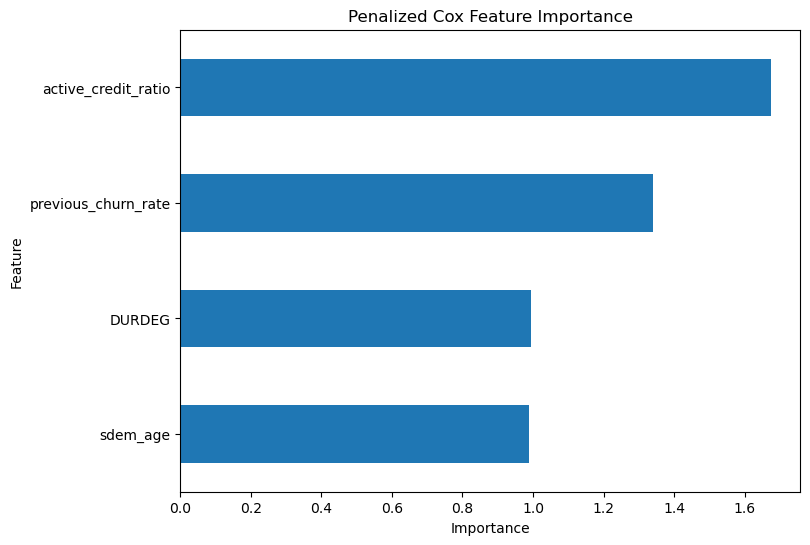

In [61]:
mask = cox_l1_sorted['coef'].abs() > 1e-4
plt.figure(figsize=(8,6))
cox_l1_sorted.loc[mask, 'exp(coef)'].sort_values(ascending=True).plot(kind='barh')
plt.title("Penalized Cox Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

O Penalized Cox sugere que as variáveis mais informativas são:
- active_credit_ratio (positivamente)
- previous_churn_rate (positivamente)
- sdem_age (negativamente)
- DURDEG (negativamente)

Apesar de L1 nao ter removido features, mostra que apenas estas 4 têm efeito

## 6.2.4 Comparações

Features fortes nos 3 modelos (provavelmente importantes):
- active_credit_ratio
- previous_churn_rate
- dividas_cl_mean
- DURDEG
- sdem_age

Features fracas nos 3 modelos (provavelmente podem ser removidas):
- montabatv_cl_mean
- SREC
- montvenc_cl_mean

Features fortes em arvores mas fracas em cox:
- count_cl_mean
- MTFINO

Ranking Combinado:
- Muito fortes
    - active_credit_ratio
    - previous_churn_rate
    - dividas_cl_mean

- Fortes
    - DURDEG
    - sdem_age
    - count_cl_mean

- Moderadas
    - MTFINO
    - is_risky
    - ks_score_tier
    - NBENF_mean

- Fracas
    - montabatv_cl_mean
    - SREC
    - montvenc_cl_mean

## Cox Proportional Hazards Model

In [36]:
cph = CoxPHFitter()

cph.fit(train_survival, duration_col='duration', event_col='event')

<lifelines.CoxPHFitter: fitted with 61316 total observations, 1691 right-censored observations>

In [37]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 61316 total observations, 1691 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 61316
number of events observed = 59625
   partial log-likelihood = -588592.26
         time fit was run = 2026-03-11 20:47:26 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
DURDEG              -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
MTFINO               0.00      1.00      0.00            0.00            0.00                1.00                1.00
SREC                 0.00      1.00      0.00            0.00            0.00                1.00                1.00
RESSO_mean           0.00      1.00      0.00            0.00            0.00                1.00                1.00
NBENF_mean          -0.03      0.97      0.00           -0.04           -0.02                0.96                0.98
previous_churn_rate  0.46      1.58      0.01            0.45            0.47                1.56                1.60
count_cl_mean        0.02      1.02      0.00            0.01            0.03                1.01                1.03
montvenc_cl_mean    -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
montabatv_cl_mean   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
dividas_cl_mean      0.00      1.00      0.00            0.00            0.00                1.00                1.00
ks_score_tier       -0.05      0.95      0.01           -0.07           -0.04                0.94                0.96
HIGH_RISK_CURRENT    0.19      1.20      0.01            0.16            0.21                1.18                1.23
is_risky            -0.09      0.91      0.01           -0.12           -0.07                0.89                0.93
sdem_age            -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
active_credit_ratio  1.15      3.15      0.03            1.09            1.21                2.97                3.34

                     cmp to      z      p  -log2(p)
covariate                                          
DURDEG                 0.00 -64.59 <0.005       inf
MTFINO                 0.00  13.51 <0.005    135.74
SREC                   0.00   9.02 <0.005     62.17
RESSO_mean             0.00  12.51 <0.005    116.81
NBENF_mean             0.00  -6.80 <0.005     36.50
previous_churn_rate    0.00  71.02 <0.005       inf
count_cl_mean          0.00   5.39 <0.005     23.78
montvenc_cl_mean       0.00  -4.55 <0.005     17.53
montabatv_cl_mean      0.00  -3.68 <0.005     12.06
dividas_cl_mean        0.00  45.02 <0.005       inf
ks_score_tier          0.00  -7.11 <0.005     39.70
HIGH_RISK_CURRENT      0.00  16.59 <0.005    203.04
is_risky               0.00  -7.49 <0.005     43.75
sdem_age               0.00 -55.51 <0.005       inf
active_credit_ratio    0.00  38.83 <0.005       inf
---
Concordance = 0.69
Partial AIC = 1177214.52
log-likelihood ratio test = 16399.66 on 15 df
-log2(p) of ll-ratio test = inf

In [38]:
train_cindex = cph.concordance_index_
val_cindex = cph.score(val_survival, scoring_method="concordance_index")
print("Train C-index:", train_cindex)
print("Validation C-index:", val_cindex)

Train C-index: 0.6853195231337426
Validation C-index: 0.6873688052838656


os valores indicam que nao houve overfitting

also, segundo esta tabela:

C-index - interpretação

0.5 - aleatório

0.6–0.7 - razoável

0.7–0.8 - bom

temos um bom desempenho para churn financeiro

## Feature Importance de numericas

In [39]:
cph.summary[['exp(coef)', 'p']].round(3).sort_values('exp(coef)', ascending = False)

,exp(coef),p
covariate,,
active_credit_ratio,3.151,0.0
previous_churn_rate,1.582,0.0
HIGH_RISK_CURRENT,1.204,0.0
count_cl_mean,1.020,0.0
SREC,1.000,0.0
RESSO_mean,1.000,0.0
MTFINO,1.000,0.0
dividas_cl_mean,1.000,0.0
montabatv_cl_mean,1.000,0.0


active_credit_ratio, previous_churn_rate, HIGH_RISK_CURRENT, count_cl_mean, SREC, RESSO_mean, dividas_cl_mean e MTFINO - assim que sobem 1 valor, aumentam a probabilidade de churn.


maior destaque a active_credit_ratio, sempre que aumenta um valor, mais que triplica a probabilidade de churn.

In [40]:
cph.summary[cph.summary['exp(coef)'] < 1]['exp(coef)'] #baixam o churn

covariate
DURDEG               0.986731
NBENF_mean           0.966863
montvenc_cl_mean     0.999984
montabatv_cl_mean    0.999935
ks_score_tier        0.949477
is_risky             0.910766
sdem_age             0.979163
Name: exp(coef), dtype: float64

In [41]:
BNP_teste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185600 entries, 0 to 185599
Data columns (total 60 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   CONTRIB                     185600 non-null  object        
 1   DOSSIER                     185600 non-null  object        
 2   is_san                      185600 non-null  int64         
 3   is_sol                      185600 non-null  int64         
 4   DCREAT                      185600 non-null  datetime64[ns]
 5   DCRD_0                      77788 non-null   datetime64[ns]
 6   CLOSE_DATE                  76646 non-null   datetime64[ns]
 7   DURDEG                      185600 non-null  Int32         
 8   RANGPRO_max                 185600 non-null  Int32         
 9   RANGCLI_max                 185600 non-null  Int32         
 10  delay_sum                   185600 non-null  int64         
 11  MENSALIDADE                 185600 non-

## categoticas

In [42]:
categorical_cols = ['PRODALP', 'POLE', 'PAGAMENTO']

One-Hot Encoding:

In [43]:
train_cat = pd.get_dummies(train_data[categorical_cols], drop_first=True)
#train_cat = train_data.copy()
val_cat = pd.get_dummies(val_data[categorical_cols], drop_first=True)
#val_cat = val_data.copy()

Frequency encoding:

In [44]:
#encoding 'model' using frequency encoding
freq_encoding_model = train_full['sdem_SITFAM'].value_counts()
train_cat['sdem_SITFAM_encoded'] = train_full['sdem_SITFAM'].map(freq_encoding_model)
val_cat['sdem_SITFAM_encoded'] = train_full['sdem_SITFAM'].map(freq_encoding_model)
test_data['sdem_SITFAM_encoded'] = test_data['sdem_SITFAM'].map(freq_encoding_model)

freq_encoding_model = train_full['kp_sqe'].value_counts()
train_cat['kp_sqe_encoded'] = train_full['kp_sqe'].map(freq_encoding_model)
val_cat['kp_sqe_encoded'] = train_full['kp_sqe'].map(freq_encoding_model)
test_data['kp_sqe_encoded'] = test_data['kp_sqe'].map(freq_encoding_model)

freq_encoding_model = train_full['sdem_HABITAT'].value_counts()
train_cat['sdem_HABITAT_encoded'] = train_full['sdem_HABITAT'].map(freq_encoding_model)
val_cat['sdem_HABITAT_encoded'] = train_full['sdem_HABITAT'].map(freq_encoding_model)
test_data['sdem_HABITAT_encoded'] = test_data['sdem_HABITAT'].map(freq_encoding_model)

freq_encoding_model = train_full['MODCONTACTO'].value_counts()
train_cat['MODCONTACTO_encoded'] = train_full['MODCONTACTO'].map(freq_encoding_model)
val_cat['MODCONTACTO_encoded'] = train_full['MODCONTACTO'].map(freq_encoding_model)
test_data['MODCONTACTO_encoded'] = test_data['MODCONTACTO'].map(freq_encoding_model)

In [45]:
train_cat, val_cat = train_cat.align(val_cat, join="left", axis=1, fill_value=0) #garantir mesmas colunas em train e val

In [46]:
X_train_full = pd.concat([X_train, train_cat], axis=1)
X_val_full = pd.concat([X_val, val_cat], axis=1)

In [47]:
train_survival_full = pd.concat([X_train_full, train_data[['duration','event']]],axis=1)

val_survival_full = pd.concat([X_val_full, val_data[['duration','event']]],axis=1)

In [48]:
cph_full = CoxPHFitter()

cph_full.fit(train_survival_full, duration_col='duration', event_col='event')

<lifelines.CoxPHFitter: fitted with 61316 total observations, 1691 right-censored observations>

In [49]:
cph_full.summary[['exp(coef)', 'p']].round(3).sort_values('exp(coef)', ascending = False)

,exp(coef),p
covariate,,
active_credit_ratio,2.861,0.000
previous_churn_rate,1.591,0.000
POLE_P,1.163,0.000
HIGH_RISK_CURRENT,1.159,0.000
is_risky,1.085,0.000
PAGAMENTO_P,1.025,0.981
count_cl_mean,1.010,0.009
MTFINO,1.000,0.000
montvenc_cl_mean,1.000,0.000


In [50]:
cph_full.print_summary()

<lifelines.CoxPHFitter: fitted with 61316 total observations, 1691 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 61316
number of events observed = 59625
   partial log-likelihood = -586570.28
         time fit was run = 2026-03-11 20:47:32 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
DURDEG               -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
MTFINO                0.00      1.00      0.00            0.00            0.00                1.00                1.00
SREC                  0.00      1.00      0.00            0.00            0.00                1.00                1.00
RESSO_mean            0.00      1.00      0.00            0.00            0.00                1.00                1.00
NBENF_mean           -0.02      0.98      0.01           -0.03           -0.01                0.97                0.99
previous_churn_rate   0.46      1.59      0.01            0.45            0.48                1.57                1.61
count_cl_mean         0.01      1.01      0.00            0.00            0.02                1.00                1.02
montvenc_cl_mean     -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
montabatv_cl_mean    -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
dividas_cl_mean       0.00      1.00      0.00            0.00            0.00                1.00                1.00
ks_score_tier        -0.11      0.90      0.01           -0.12           -0.09                0.88                0.91
HIGH_RISK_CURRENT     0.15      1.16      0.01            0.13            0.17                1.13                1.18
is_risky              0.08      1.08      0.02            0.05            0.11                1.05                1.12
sdem_age             -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
active_credit_ratio   1.05      2.86      0.03            0.99            1.11                2.70                3.03
PRODALP_EP           -0.61      0.54      0.03           -0.68           -0.54                0.51                0.58
PRODALP_EPF          -0.49      0.61      0.04           -0.56           -0.42                0.57                0.65
PRODALP_EXT          -0.25      0.78      0.04           -0.32           -0.18                0.72                0.84
POLE_P                0.15      1.16      0.04            0.08            0.23                1.08                1.25
PAGAMENTO_N          -0.95      0.39      1.00           -2.91            1.01                0.05                2.75
PAGAMENTO_P           0.02      1.02      1.00           -1.94            1.98                0.14                7.27
sdem_SITFAM_encoded  -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
kp_sqe_encoded       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
sdem_HABITAT_encoded -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
MODCONTACTO_encoded   0.00      1.00      0.00            0.00            0.00                1.00                1.00

                      cmp to      z      p  -log2(p)
covariate                                           
DURDEG                  0.00 -67.42 <0.005       inf
MTFINO                  0.00   8.31 <0.005     53.21
SREC                    0.00   8.35 <0.005     53.74
RESSO_mean              0.00  15.96 <0.005    188.14
NBENF_mean              0.00  -3.53 <0.005     11.22
previous_churn_rate     0.00  71.68 <0.005  

In [51]:
train_cindex_full = cph_full.concordance_index_
val_cindex_full = cph_full.score(val_survival_full, scoring_method="concordance_index")
print("Train C-index:", train_cindex_full)
print("Validation C-index:", val_cindex_full)

Train C-index: 0.6961213967042896
Validation C-index: 0.6915778072289195
